# Wizualizacja danych w Pythonie
## Matplotlib & Seaborn — od podstaw

**Dane:** Pingwiny Palmer  
**Biblioteki:** `matplotlib`, `seaborn`, `pandas`, `numpy`


---
## 0. Import bibliotek

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
## 1. Matplotlib od podstaw


Matplotlib rysuje na dwóch obiektach:
- **Figure** — cała "kartka papieru"
- **Axes** — jeden wykres (osie, dane, tytuł)

Minimalna recepta:
```python
plt.figure()          # nowa kartka
plt.plot(x, y)        # narysuj dane
plt.show()            # wyświetl
```

### 1.1 Jak narysować prostą

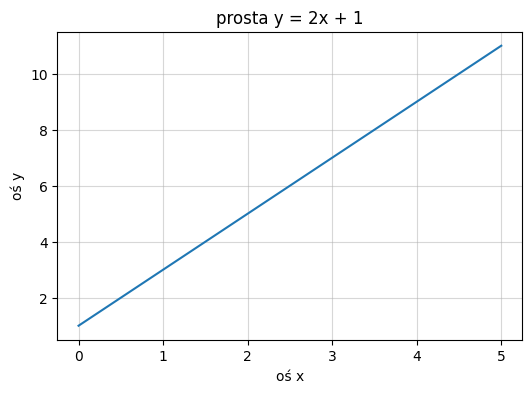

In [2]:
# prosta y = 2x + 1
x = [0, 1, 2, 3, 4, 5]
y = [1, 3, 5, 7, 9, 11]

plt.figure(figsize=(6, 4))        # rozmiar figury w calach (szerokość, wysokość)
plt.plot(x, y)                    # rysuje linię łączącą punkty po kolei
plt.xlabel('oś x')
plt.ylabel('oś y')
plt.title('prosta y = 2x + 1')
plt.grid(True, alpha=0.5)         # siatka pomocnicza, alpha = przezroczystość, true to grid się pojawia
plt.show()

### 1.2 Jak postawić punkt (scatter)

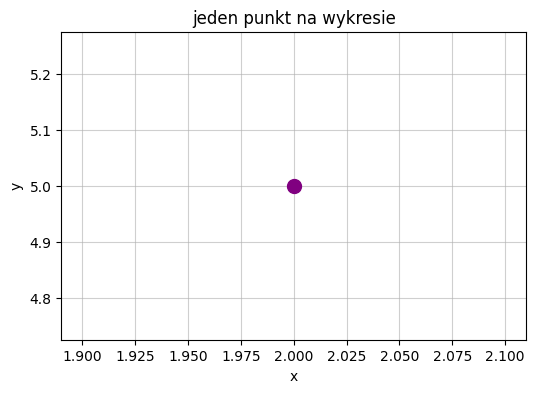

In [3]:
# plt.scatter rysuje pojedyncze punkty, nie łączy ich linią
x_punkt = [2]
y_punkt = [5]

plt.figure(figsize=(6, 4))
plt.scatter(x_punkt, y_punkt,
            color='purple',    # kolor punktu
            s=100,          # rozmiar punktu (domyślnie 36)) 
            zorder = 2)     # zorder decyduje co jest "na wierzchu"
plt.xlabel('x')
plt.ylabel('y')
plt.title('jeden punkt na wykresie')
plt.grid(True, alpha=0.6)
plt.show()

### 1.3 Punkty połączone prostą

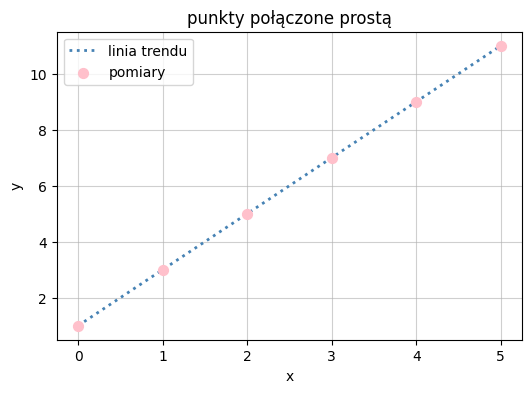

In [4]:
# plt.plot i plt.scatter można łączyć na jednym wykresie
# dwa wywołania przed plt.show() rysują na tej samej figurze

x = [0, 1, 2, 3, 4, 5]
y = [1, 3, 5, 7, 9, 11]

plt.figure(figsize=(6, 4))

# linia
plt.plot(x, y,
         color='steelblue',
         linewidth=2,
         linestyle=':',    # '--' przerywana, '-' ciągła, ':' kropkowana
         label='linia trendu')

# punkty na tej samej figurze
plt.scatter(x, y,
            color='pink',
            s=50,
            zorder=5,
            label='pomiary')

plt.xlabel('x')
plt.ylabel('y')
plt.title('punkty połączone prostą')
plt.legend()               # legenda — bierze etykiety z label=
plt.grid(True, alpha=0.6)
plt.show()

### Zadanie 1

Narysuj na jednym wykresie dwie proste:
- `y1 = x` (kolor zielony, linia ciągła)
- `y2 = x**2` (kolor pomarańczowy, linia przerywana `'--'`)

Zakres x: `[0, 1, 2, 3, 4]`  
Dodaj tytuł, etykiety osi i legendę.

> 💡 Dwa razy `plt.plot(...)` przed `plt.show()` rysuje obie linie na jednym wykresie.

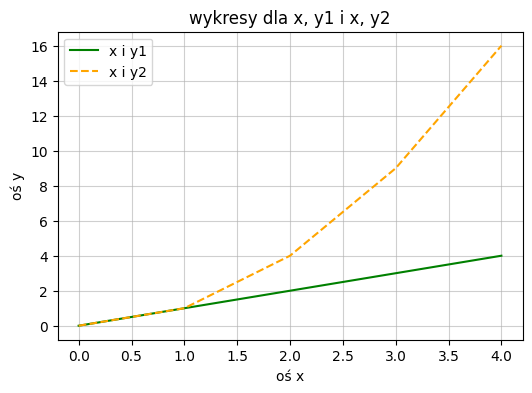

In [5]:
x = [0, 1, 2, 3, 4]
y1 = x
#UWAGA wyrażeie listowe  →łądnie skraca kod
y2 = [x1**2 for x1 in x]

plt.figure(figsize=(6, 4))

plt.plot(x, y1,
         color="green",
         linestyle="-",
         label="x i y1",
        )

plt.plot(x, y2,
         color="orange",
         linestyle="--",
         label="x i y2",
        )


plt.xlabel('oś x')
plt.ylabel('oś y')
plt.title('wykresy dla x, y1 i x, y2')
plt.legend()
plt.grid(True, alpha=0.6)
plt.show()


---
## 2. Wgrywanie danych i eksploracja


### 2.1 Wczytanie danych

In [6]:
# zbiór Palmer Penguins — wbudowany w Seaborn, nie trzeba nic pobierać
pewpew = sns.load_dataset('penguins')

# jak wyświetlić pierwsze 7 wierszy?
pewpew.head(7)
#wystepuja braki :()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,Female


### 2.2 Podstawowe informacje o zbiorze

In [7]:
# wyświetlamy wymiar danych: (wiersze, kolumny)
print('wymiar:', pewpew.shape)
print()

# wyświetlamy typy kolumn i liczba braków
print('typy kolumn i braki:')
print(pewpew.info())

wymiar: (344, 7)

typy kolumn i braki:
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB
None


In [8]:
# czy są braki w danych?
print('liczba braków w każdej kolumnie:')
print(pewpew.isna().sum())
print()
print(f'wierszy z co najmniej jednym brakiem: {pewpew.isnull().any(axis=1).sum()}')

liczba braków w każdej kolumnie:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

wierszy z co najmniej jednym brakiem: 11


In [9]:
# podstawowe statystyki opisowe dla kolumn liczbowych
pewpew.describe().round(2)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.00,342.00,342.00,342.00
mean,43.92,17.15,200.92,4201.75
std,5.46,1.97,14.06,801.95
min,32.10,13.10,172.00,2700.00
25%,39.22,15.60,190.00,3550.00
50%,44.45,17.30,197.00,4050.00
75%,48.50,18.70,213.00,4750.00
max,59.60,21.50,231.00,6300.00


In [10]:
# Ile pingwinów każdego gatunku?
print('Liczba pingwinów wg gatunku:')
# kolumna species
print(pewpew["species"].value_counts())
print()
# kolumna island
print('Liczba pingwinów wg wyspy:')
print(pewpew["island"].value_counts())

Liczba pingwinów wg gatunku:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

Liczba pingwinów wg wyspy:
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64


In [11]:
# usuwamy wiersze z brakami — reszta zajęć na czystych danych
ping = pewpew.dropna().reset_index(drop=True)
print(f'Wierszy po usunięciu braków: {len(ping)}')

# słownik kolorów — używamy go przez cały notatnik dla spójności
KOLORY = {'Adelie': "#D6B583", 'Gentoo': "#6FC4B7", 'Chinstrap': "#BC86DB"}

Wierszy po usunięciu braków: 333


###  Zadanie 2

1. Ile jest unikalnych wartości w kolumnie `island`? 
2. Jaka jest średnia masa ciała (`body_mass_g`) dla każdego gatunku?  
3. Ile pingwinów to samce, ile samice? 

In [12]:
# 1. Unikalne wyspy
w = ping["island"].nunique()
# 2. Średnia masa wg gatunku
m = ping.groupby("species")["body_mass_g"].mean()
# 3. Podział na płeć
s = ping["sex"].value_counts()

print(f'''{w},
{m}
{s}''')

3,
species
Adelie       3706.164384
Chinstrap    3733.088235
Gentoo       5092.436975
Name: body_mass_g, dtype: float64
sex
Male      168
Female    165
Name: count, dtype: int64


---
## 3. Pie chart — rozkład klas


Pie chart przydaje się gdy chcemy pokazać **udziały procentowe** kategorii.  
Używamy go gdy mamy 2–5 kategorii — przy większej liczbie trudno odczytać wartości.

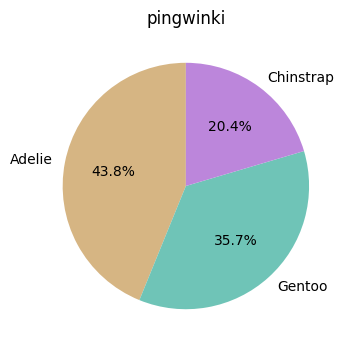

In [13]:
# zliczamy pingwiny wg gatunku
species = ping["species"].value_counts()

#na piechart umieszcza sie od 3-5 czesci bo inaczej jest nieczytelny
plt.figure(figsize=(6, 4))
plt.pie(
    species.values,
    labels=species.index,
    colors=list(KOLORY.values()),
    autopct="%1.1f%%", #wyświetlanie procentow jako tekst w etykietach, a % to znak specjalny
    startangle=90
    )  
plt.title("pingwinki", fontsize=12)
plt.show()

###  Zadanie 3

Narysuj pie chart pokazujący **rozkład wysp** (kolumna `island`), nie gatunków.  
Użyj dowolnych kolorów. Dodaj tytuł.

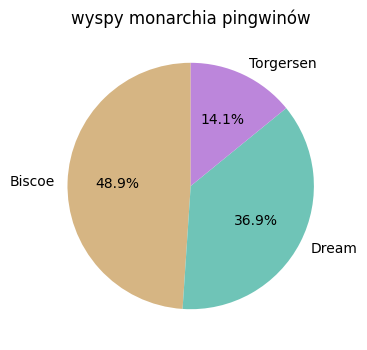

In [14]:
isln = ping["island"].value_counts()

plt.figure(figsize=(6, 4))
plt.pie(
    isln.values,
    labels=isln.index,
    colors=list(KOLORY.values()),
    autopct="%1.1f%%",
    startangle=90
    )  
plt.title("wyspy monarchia pingwinów", fontsize=12)
plt.show()

---
## 4. Histogram — rozkład jednej zmiennej


Histogram dzieli zakres wartości na przedziały (`bins`) i liczy ile obserwacji wpada do każdego.  
Używamy go do sprawdzenia **kształtu rozkładu** — czy jest normalny, skośny, wielomodalny.

### 4.1 Podstawowy histogram

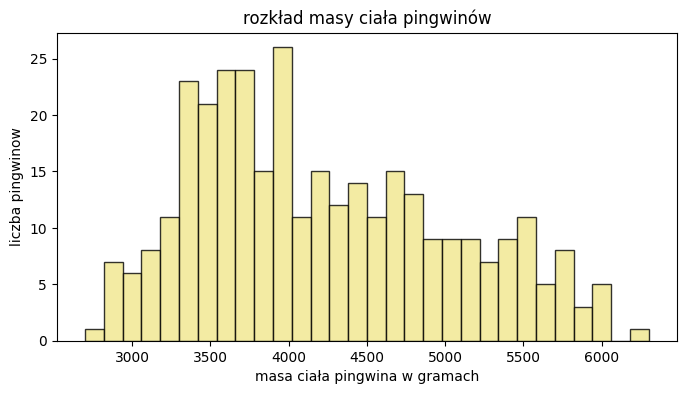

In [15]:
plt.figure(figsize=(8, 4))

plt.hist(
    ping["body_mass_g"],
    bins=30,
    color="khaki",
    #dla czytelnosci nizej
    edgecolor="black",
    alpha=0.8
    )

plt.xlabel("masa ciała pingwina w gramach")
plt.ylabel("liczba pingwinow")
plt.title("rozkład masy ciała pingwinów")

plt.show()

### 4.2 axvline — linie dla mediany i średniej

Kiedy chcemy zaznaczyć na histogramie konkretną wartość (próg, statystykę) — używamy `plt.axvline()`.

In [16]:
srednia = ping["body_mass_g"].mean()
mediana = ping["body_mass_g"].median()
print(f'Srednia: {srednia:.0f} g')
print(f'Mediana: {mediana:.0f} g')

Srednia: 4207 g
Mediana: 4050 g


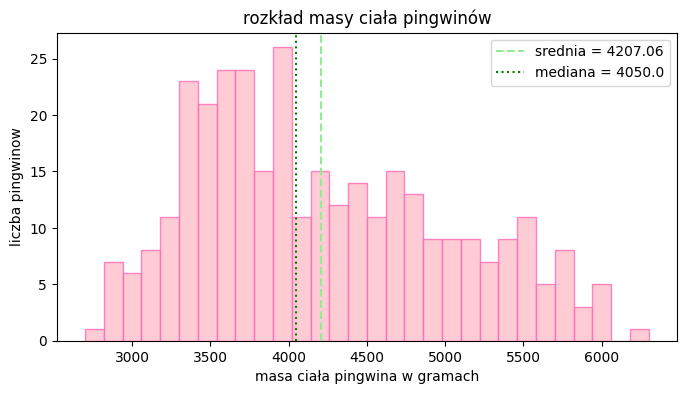

In [17]:
plt.figure(figsize=(8, 4))

plt.hist(
    ping["body_mass_g"],
    bins=30,
    color="pink",
    #dla czytelnosci nizej
    edgecolor="hotpink",
    alpha=0.8
    )

plt.axvline(x = srednia, color="lightgreen", linestyle="--", label=f"srednia = {srednia.round(2)}")
plt.axvline(x = mediana, color="green", linestyle=":", label=f"mediana = {mediana}")

plt.xlabel('masa ciała pingwina w gramach')
plt.ylabel("liczba pingwinow")
plt.title("rozkład masy ciała pingwinów")
plt.legend()

plt.show()

### 4.3 Histogram z podziałem na gatunki

Żeby zobaczyć rozkłady osobno dla każdego gatunku — rysujemy kilka histogramów na jednym wykresie.  
Kluczowe: `alpha` (przezroczystość) żeby się nie zasłaniały.

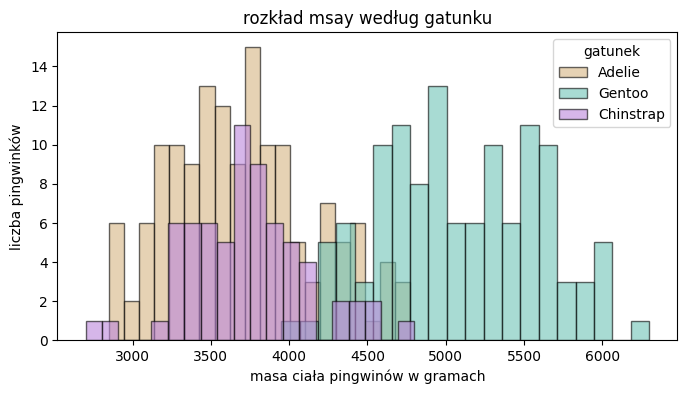

In [18]:
plt.figure(figsize=(8, 4))

for spec, kolor in KOLORY.items():
    dane = ping[ping["species"] == spec]["body_mass_g"]
    plt.hist(
        dane,
        bins=20,
        alpha=0.6,
        color=kolor,
        edgecolor="black",
        label=spec
    )

plt.xlabel("masa ciała pingwinów w gramach")
plt.ylabel("liczba pingwinków")
plt.title("rozkład msay według gatunku")
plt.legend(title="gatunek")

plt.show()

###  Zadanie 4

1. Narysuj histogram **długości dzioba** (`bill_length_mm`) dla całego zbioru.  
   Dodaj linie dla mediany i średniej.

2. Narysuj drugi histogram tej samej cechy, ale z podziałem na gatunki (pętla + `alpha=0.6`).

3. **Pytanie:** Histogram z punktu 1 ma dwa garby. Dlaczego? Co wyjaśnia histogram z punktu 2?

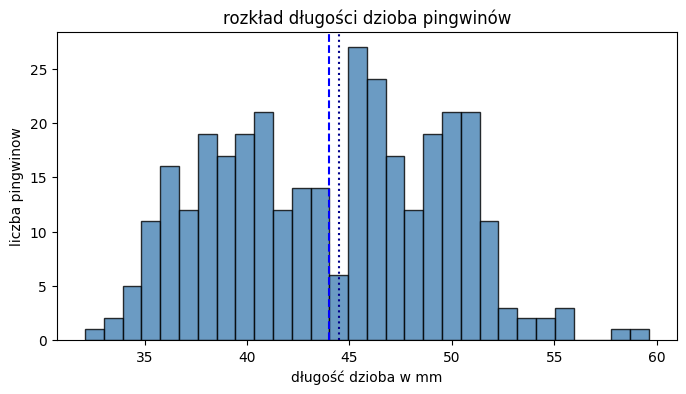

In [19]:
# Twoje rozwiązanie — wykres 1:
plt.figure(figsize=(8, 4))

plt.hist(
    ping["bill_length_mm"],
    bins=30,
    color="steelblue",
    edgecolor="black",
    alpha=0.8
    )

sd = ping["bill_length_mm"].mean().round(2)
md = ping["bill_length_mm"].median()

plt.axvline(x = sd, color="blue", linestyle="--", label=f"srednia = {sd}")
plt.axvline(x = md, color="darkblue", linestyle=":", label=f"mediana = {md}")

plt.xlabel("długość dzioba w mm")
plt.ylabel("liczba pingwinow")
plt.title("rozkład długości dzioba pingwinów")

plt.show()

Text(0.5, 1.0, 'rozkład długości dzioba pingwinów')

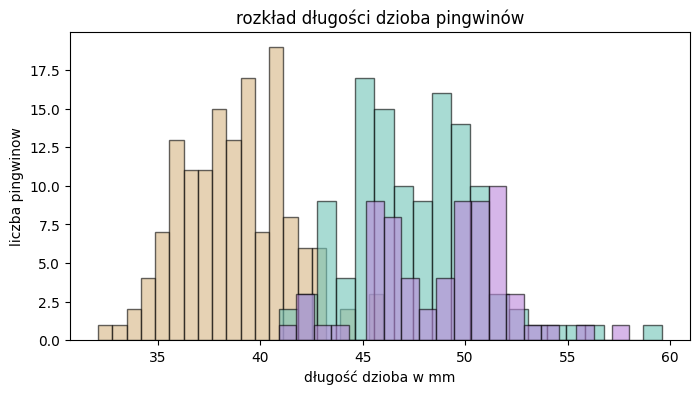

In [20]:
# Twoje rozwiązanie — wykres 2:
plt.figure(figsize=(8, 4))

for spec, kolor in KOLORY.items():
    dane = ping[ping["species"] == spec]["bill_length_mm"]
    plt.hist(
        dane,
        bins=20,
        alpha=0.6,
        color=kolor,
        edgecolor="black",
        label=spec
    )

plt.xlabel("długość dzioba w mm")
plt.ylabel("liczba pingwinow")
plt.title("rozkład długości dzioba pingwinów")

---
## 5. Boxplot i Violinplot — dane odstające i rozkład


### Jak czytać boxplot?

```
         |--wąs--|  [  Q1 | mediana | Q3  ]  |--wąs--|  o (outlier)
```

- **Pudełko** = zakres między Q1 (25%) a Q3 (75%) — tu mieszka środkowe 50% danych
- **Linia środkowa** = mediana
- **Wąsy** = maksymalnie 1.5 × IQR poza pudełkiem
- **Punkty poza wąsami** = potencjalne wartości odstające (outliery)

/tmp/ipykernel_168766/3217595350.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(grupy, labels=etykiety, patch_artist=True, notch=True)


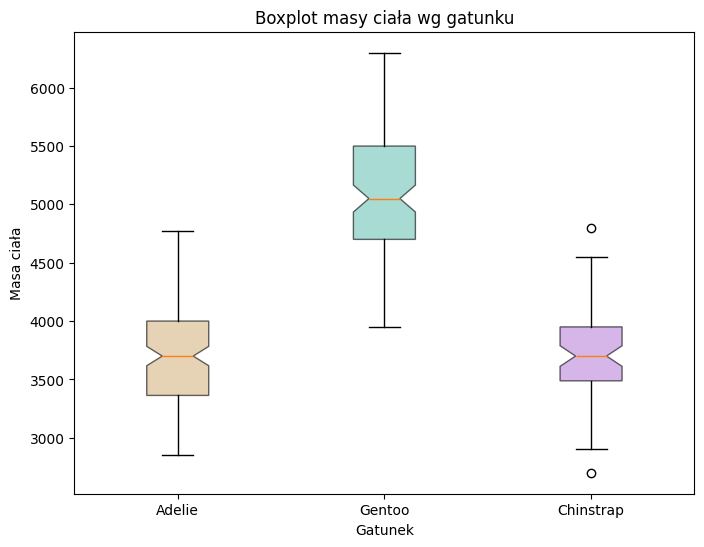

In [21]:
grupy = [ping[ping['species'] == g]['body_mass_g'] for g in KOLORY.keys()]
etykiety = list(KOLORY.keys())
plt.figure(figsize=(8, 6))
bp = plt.boxplot(grupy, labels=etykiety, patch_artist=True, notch=True)
for patch, kolor in zip(bp['boxes'], KOLORY.values()):
    patch.set_facecolor(kolor)
    patch.set_alpha(0.6)
plt.xlabel('Gatunek')
plt.ylabel('Masa ciała')
plt.title('Boxplot masy ciała wg gatunku')
plt.show()

### 5.1 Podstawowy boxplot

In [22]:
COLORY = {
    'Adelie': '#FFB7CE',    # Ładny, miękki pastelowy róż
    'Gentoo': '#AEC6CF',    # Spokojny pastelowy błękit
    'Chinstrap': '#C3B1E1'  # Delikatny, lawendowy fiolet
}

/tmp/ipykernel_168766/1709803287.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(grupy, labels=etykiety, patch_artist=True, notch=True)


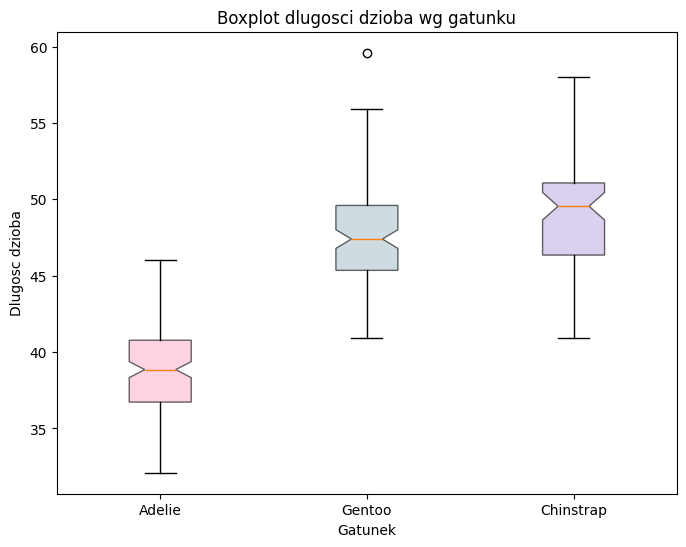

In [23]:
grupy = [ping[ping['species'] == g]['bill_length_mm'] for g in COLORY.keys()]
etykiety = list(COLORY.keys())
plt.figure(figsize=(8, 6))
bp = plt.boxplot(grupy, labels=etykiety, patch_artist=True, notch=True)
for patch, kolor in zip(bp['boxes'], COLORY.values()):
    patch.set_facecolor(kolor)
    patch.set_alpha(0.6)
plt.xlabel('Gatunek')
plt.ylabel('Dlugosc dzioba')
plt.title('Boxplot dlugosci dzioba wg gatunku')
plt.show()

### 5.2 Boxplot z podziałem na płeć

Chcemy zobaczyć czy samce i samice różnią się masą ciała w obrębie każdego gatunku.  
Tu z pomocą przychodzi Seaborn — jedną linią robimy to co w Matplotlib wymagałoby wielu pętli.

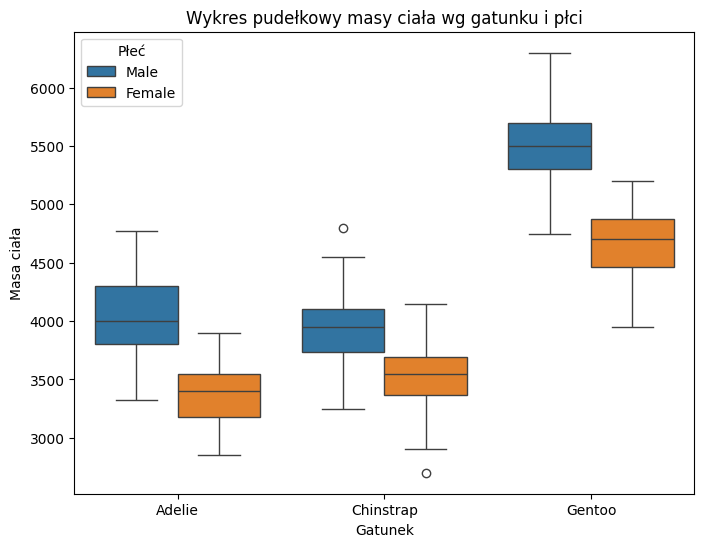

In [24]:
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.boxplot(data=ping, x='species', y='body_mass_g', hue='sex')
plt.xlabel('Gatunek')
plt.ylabel('Masa ciała')
plt.title('Wykres pudełkowy masy ciała wg gatunku i płci')
plt.legend(title='Płeć', loc = 'upper left')
plt.show()

### 5.3 Violinplot

Violinplot łączy boxplot z rozkładem gęstości.  
Szerokość "skrzypiec" = gęstość prawdopodobieństwa w danym miejscu — im szerzej, tym więcej obserwacji.

/tmp/ipykernel_168766/4294292693.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=ping, x='species', y='body_mass_g', palette=list(COLORY.values()))


Text(0.5, 1.0, 'Wykres wiolinowy masy ciała wg gatunku')

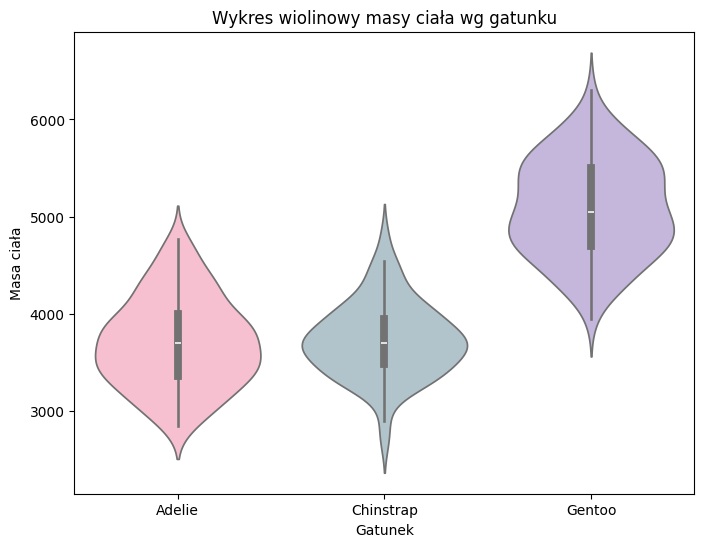

In [25]:
plt.figure(figsize=(8, 6))
sns.violinplot(data=ping, x='species', y='body_mass_g', palette=list(COLORY.values()))
plt.xlabel('Gatunek')
plt.ylabel('Masa ciała')
plt.title('Wykres wiolinowy masy ciała wg gatunku')

### Zadanie 5

1. Narysuj boxplot dla **długości dzioba** (`bill_length_mm`) — podział wg gatunku.  
   Pokoloruj pudełka kolorami z `KOLORY`.

2. Narysuj violinplot dla **głębokości dzioba** (`bill_depth_mm`) z podziałem na płeć (`hue='sex'`).

3. **Pytanie:** Który gatunek ma największy rozrzut masy ciała (najszersze pudełko)?

/tmp/ipykernel_168766/1919392418.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ping, x='species', y='bill_length_mm', palette=[COLORY[gatunek] for gatunek in ping['species'].unique()])
/tmp/ipykernel_168766/1919392418.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Płeć', loc = 'upper left')


Text(0.5, 1.0, 'Wykres pudełkowy dlugosci dzioba wg gatunku')

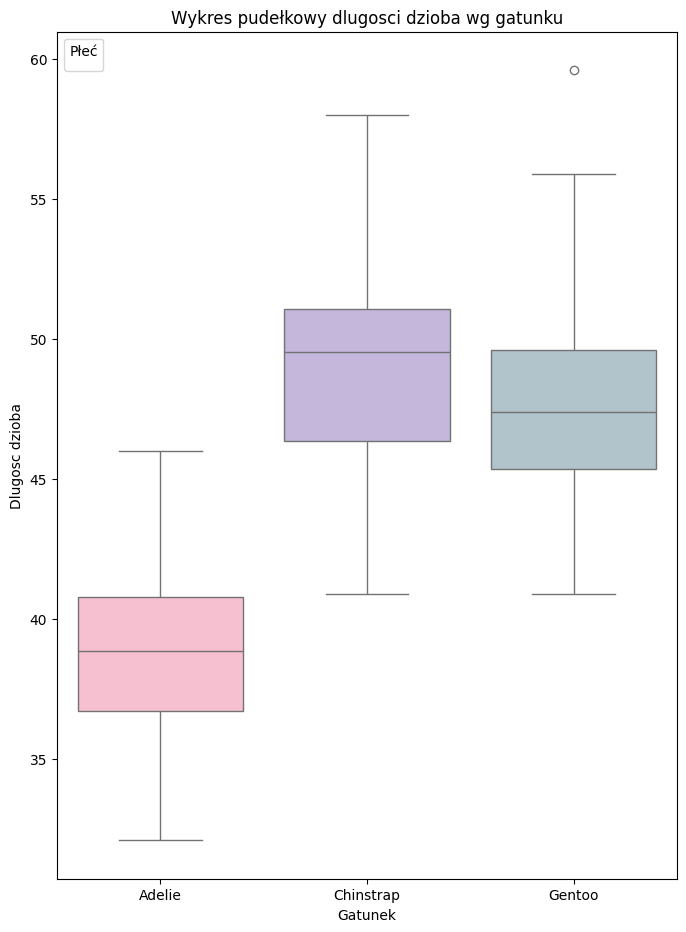

In [26]:
# Twoje rozwiązanie — boxplot:
plt.figure(figsize=(8,11))
sns.boxplot(data=ping, x='species', y='bill_length_mm', palette=[COLORY[gatunek] for gatunek in ping['species'].unique()])
plt.xlabel('Gatunek')
plt.ylabel('Dlugosc dzioba')
plt.legend(title='Płeć', loc = 'upper left')
plt.title('Wykres pudełkowy dlugosci dzioba wg gatunku')

/tmp/ipykernel_168766/3884128414.py:3: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.violinplot(data=ping, x='species', y='bill_length_mm', hue ='sex', split=True, palette=list(COLORY.values()))


Text(0.5, 1.0, 'Wykres wiolinowy dlugosci dzioba wg gatunku i płci')

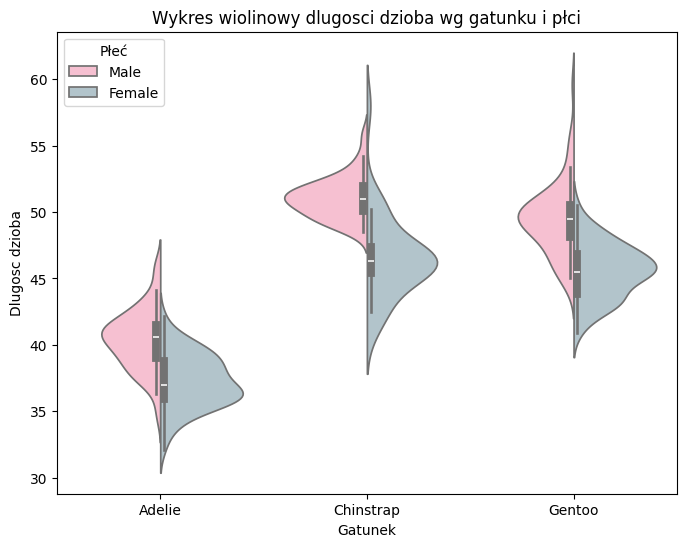

In [27]:
# Twoje rozwiązanie — violinplot:
plt.figure(figsize=(8, 6))
sns.violinplot(data=ping, x='species', y='bill_length_mm', hue ='sex', split=True, palette=list(COLORY.values()))
plt.xlabel('Gatunek')
plt.ylabel('Dlugosc dzioba')
plt.legend(title='Płeć', loc = 'upper left')
plt.title('Wykres wiolinowy dlugosci dzioba wg gatunku i płci')

---
## 6. Scatter plot i adnotacje


Scatter plot pokazuje zależność między dwiema zmiennymi ciągłymi. Każdy punkt = jeden pingwin.

### 6.1 Podstawowy scatter plot

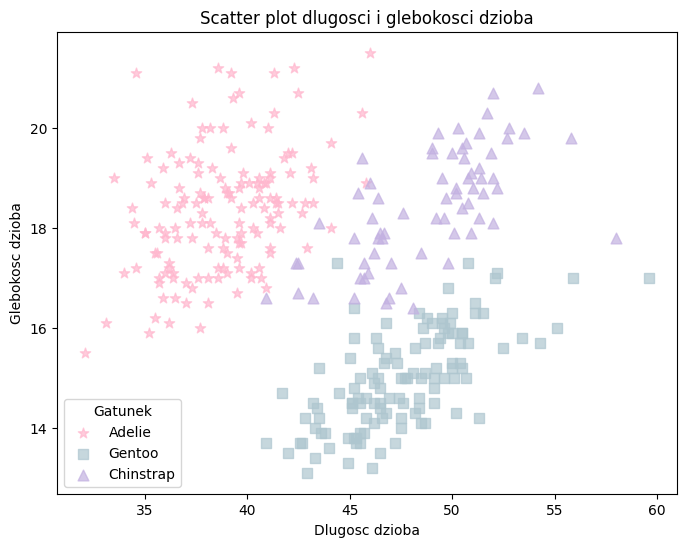

In [28]:
plt.figure(figsize=(8, 6))
markery = {'Adelie' : '*', 'Gentoo' : 's', 'Chinstrap' : '^'}
for gatunek, kolor in COLORY.items():
  pod = ping[ping['species']==gatunek]
  plt.scatter(pod['bill_length_mm'], pod['bill_depth_mm'], c=kolor, label=gatunek, s =60, marker =markery[gatunek], alpha = 0.7 )
plt.xlabel('Dlugosc dzioba')
plt.ylabel('Glebokosc dzioba')
plt.title('Scatter plot dlugosci i glebokosci dzioba')
plt.legend(title = 'Gatunek', loc = 'lower left')
plt.show()

### 6.2 Oznaczenie konkretnego punktu — plt.annotate

`plt.annotate` rysuje strzałkę wskazującą konkretny punkt danych.  
Przydatne gdy chcemy zwrócić uwagę na outlier, rekord, lub konkretnego osobnika.

In [29]:
# Znajdźmy najcięższego pingwina
idx_max = ping['body_mass_g'].idxmax()
x_max = ping.loc[idx_max, 'flipper_length_mm']
y_max = ping.loc[idx_max, 'body_mass_g']
g_max = ping.loc[idx_max, 'species']
print(f"Najcięższy pingwin: {ping['body_mass_g'][idx_max]}g, {g_max}")

Najcięższy pingwin: 6300.0g, Gentoo


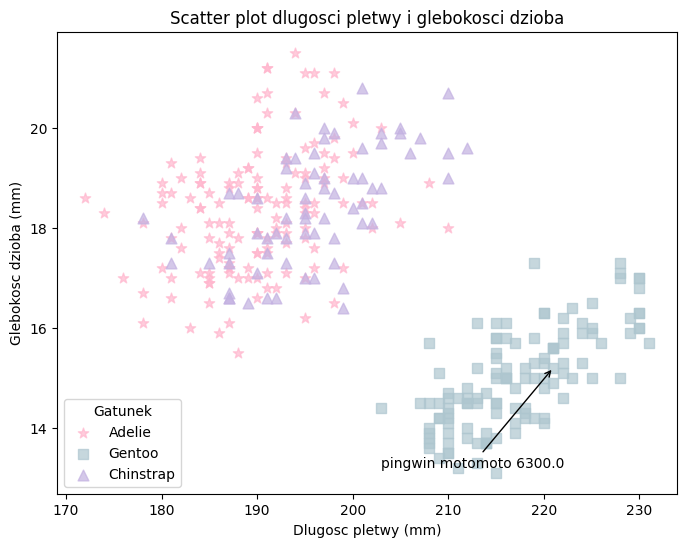

In [30]:
plt.figure(figsize=(8, 6))
markery = {'Adelie' : '*', 'Gentoo' : 's', 'Chinstrap' : '^'}
for gatunek, kolor in COLORY.items():
  pod = ping[ping['species']==gatunek]
  plt.scatter(pod['flipper_length_mm'], pod['bill_depth_mm'], c=kolor, label=gatunek, s =60, marker =markery[gatunek], alpha = 0.7 )
plt.annotate(text = f"pingwin motomoto {ping['body_mass_g'][idx_max]}", xy = (x_max, ping.loc[idx_max, 'bill_depth_mm']), xytext = (x_max-18, ping.loc[idx_max, 'bill_depth_mm']-2),
             arrowprops={'arrowstyle' : '->', 'color': 'black'})
plt.xlabel('Dlugosc pletwy (mm)')
plt.ylabel('Glebokosc dzioba (mm)')
plt.title('Scatter plot dlugosci pletwy i glebokosci dzioba')
plt.legend(title = 'Gatunek', loc = 'lower left')
plt.show()

### Zadanie 6

Na scatter plot `bill_length_mm` vs `bill_depth_mm`:
1. Narysuj wszystkie trzy gatunki różnymi kolorami z `KOLORY`
2. Znajdź pingwina z **najdłuższym dziobem**: `df['bill_length_mm'].idxmax()`
3. Oznacz go strzałką `plt.annotate` z tekstem zawierającym długość dzioba i gatunek

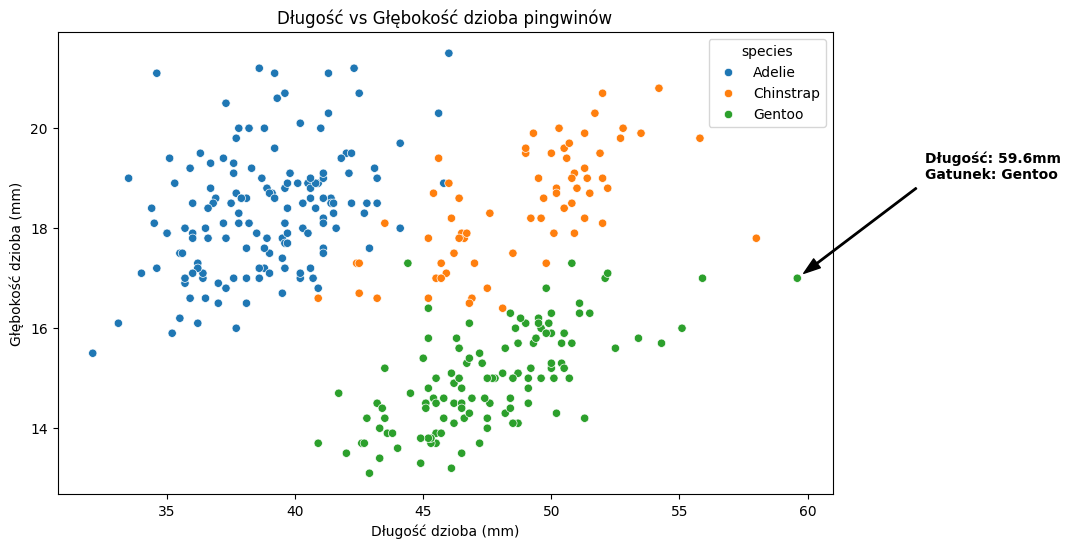

In [31]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=ping, x='bill_length_mm', y='bill_depth_mm', hue='species')

idx_max = ping['bill_length_mm'].idxmax()
longest_bill_row = ping.loc[idx_max]

x_val = longest_bill_row['bill_length_mm']
y_val = longest_bill_row['bill_depth_mm']
species = longest_bill_row['species']

plt.annotate(
    f'Długość: {x_val}mm\nGatunek: {species}', 
    xy=(x_val, y_val),
    xytext=(x_val + 5, y_val + 2),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
    fontsize=10,
    fontweight='bold'
)

plt.title('Długość vs Głębokość dzioba pingwinów')
plt.xlabel('Długość dzioba (mm)')
plt.ylabel('Głębokość dzioba (mm)')
plt.show()



---
## 7. Heatmapa korelacji


Korelacja mierzy siłę i kierunek zależności liniowej między dwiema zmiennymi:
- **+1** — pełna korelacja dodatnia (razem rosną)
- **0** — brak korelacji
- **-1** — pełna korelacja ujemna (jedna rośnie, druga maleje)

Macierz korelacji zestawia wszystkie pary zmiennych naraz.

In [32]:
# Wybieramy tylko kolumny liczbowe i liczymy korelacje
cechy    = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
etykiety = ['Dl. dzioba', 'Gl. dzioba', 'Dl. pletwy', 'Masa ciala']

corr = ping[cechy].corr()
print(corr.round(2))
#to pokazuje ciężką do czytania macierz

                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm               1.00          -0.23               0.65   
bill_depth_mm               -0.23           1.00              -0.58   
flipper_length_mm            0.65          -0.58               1.00   
body_mass_g                  0.59          -0.47               0.87   

                   body_mass_g  
bill_length_mm            0.59  
bill_depth_mm            -0.47  
flipper_length_mm         0.87  
body_mass_g               1.00  


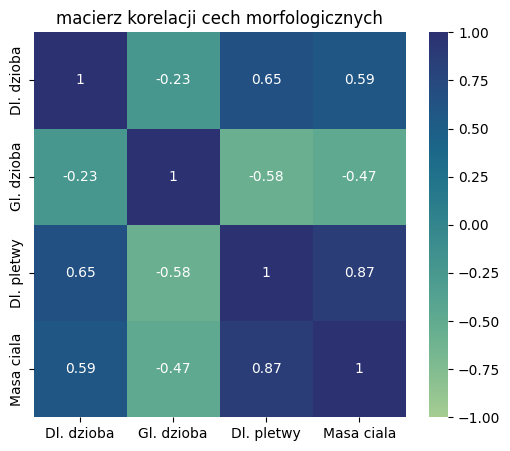

In [33]:
plt.figure(figsize=(6,5))
sns.heatmap(corr,
            annot=True, #pokazuje wartosc na kazdym kafelku macierzy
            cmap="crest", #zmiana map kolorów
            vmin= -1, vmax= 1, #ustawia skale (z boku)
            xticklabels=etykiety, #dodanie custom etykiet
            yticklabels=etykiety,
            )

plt.title("macierz korelacji cech morfologicznych")
#plt.savefig("macierz_ciepła_pingwinki.png") #zapisywanie obrazu ZAWSZE przed plt.show()
plt.show()

### Zadanie 7

1. Przeczytaj macierz korelacji: która para cech ma **największą korelację dodatnią**?
2. Czy jest para cech z **korelacją ujemną**? Jakie to cechy?
3. **Opcjonalne:** Policz korelacje osobno dla gatunku Gentoo:  
   `corr_gentoo = df[df['species']=='Gentoo'][cechy].corr()`  
   Czy korelacje są inne niż dla całego zbioru?

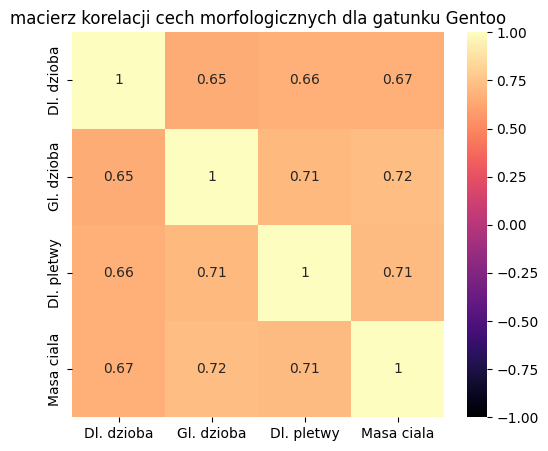

In [34]:
# Twoje odpowiedzi:
# 1. masa ciała i długość płetwy
# 2. głębokość dzioba i długość płetwy

# Opcjonalne — korelacje dla Gentoo:
corr_gento = ping[ping["species"]=="Gentoo"][cechy].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_gento,
            annot=True, #pokazuje wartosc na kazdym kafelku macierzy
            cmap="magma", #zmiana map kolorów
            vmin= -1, vmax= 1, #ustawia skale (z boku)
            xticklabels=etykiety, #dodanie custom etykiet
            yticklabels=etykiety,
            )

plt.title("macierz korelacji cech morfologicznych dla gatunku Gentoo")
plt.show()


---
## 8. Subplots — kilka wykresów obok siebie


`plt.subplots(wiersze, kolumny)` tworzy siatkę wykresów na jednej figurze.  
Zwraca dwa obiekty: `fig` (cała figura) i `axes` (tablica osi).

```python
fig, axes = plt.subplots(1, 2)   # 1 wiersz, 2 kolumny
#  axes[0] — lewy wykres
#  axes[1] — prawy wykres
```

Ważna różnica: zamiast `plt.xlabel()` używamy `axes[i].set_xlabel()`

### 8.1 Trzy histogramy poziomo (1 wiersz, 3 kolumny)

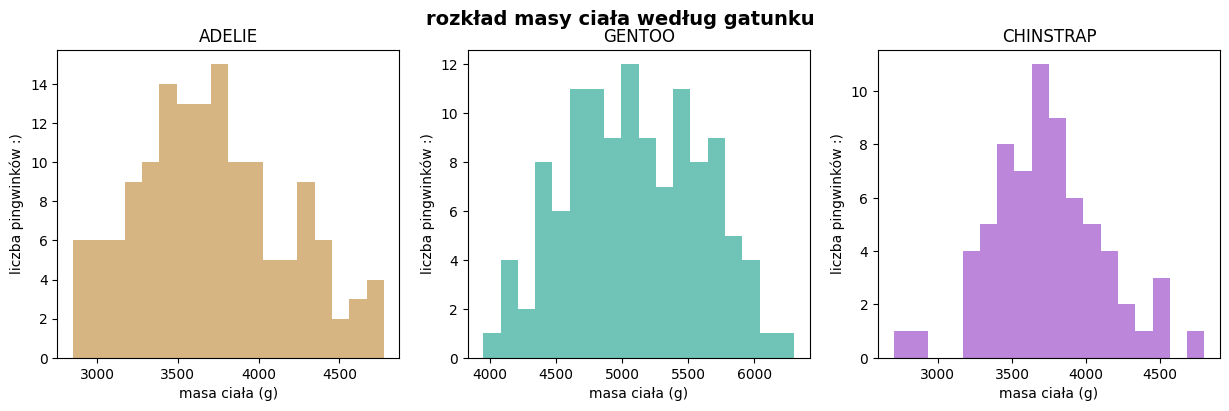

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

axes[0].hist(ping[ping["species"]=="Adelie"]["body_mass_g"], color=KOLORY["Adelie"], bins=18)
axes[0].set_xlabel("masa ciała (g)")
axes[0].set_ylabel("liczba pingwinków :)")
axes[0].set_title("ADELIE")

axes[1].hist(ping[ping["species"]=="Gentoo"]["body_mass_g"], color=KOLORY["Gentoo"], bins=18)
axes[1].set_xlabel("masa ciała (g)")
axes[1].set_ylabel("liczba pingwinków :)")
axes[1].set_title("GENTOO")

axes[2].hist(ping[ping["species"]=="Chinstrap"]["body_mass_g"], color=KOLORY["Chinstrap"], bins=18)
axes[2].set_xlabel("masa ciała (g)")
axes[2].set_ylabel("liczba pingwinków :)")
axes[2].set_title("CHINSTRAP")

fig.suptitle("rozkład masy ciała według gatunku", fontsize=14, fontweight="bold")
plt.show()

#albo pojedynczy albo takie laczne wykresy, nie mozna tutaj dołożyć jakiegos wczesniejszego wykresu
#jesli wiemy ze bedziemy czesto uzywac danego wykresu to napisac sobie funkcje po prostu z tego (albo pobrac obrazy)

### 8.2 Trzy histogramy pionowo (3 wiersze, 1 kolumna)

Zmieniamy tylko `subplots(3, 1)` i `figsize` — reszta kodu identyczna.

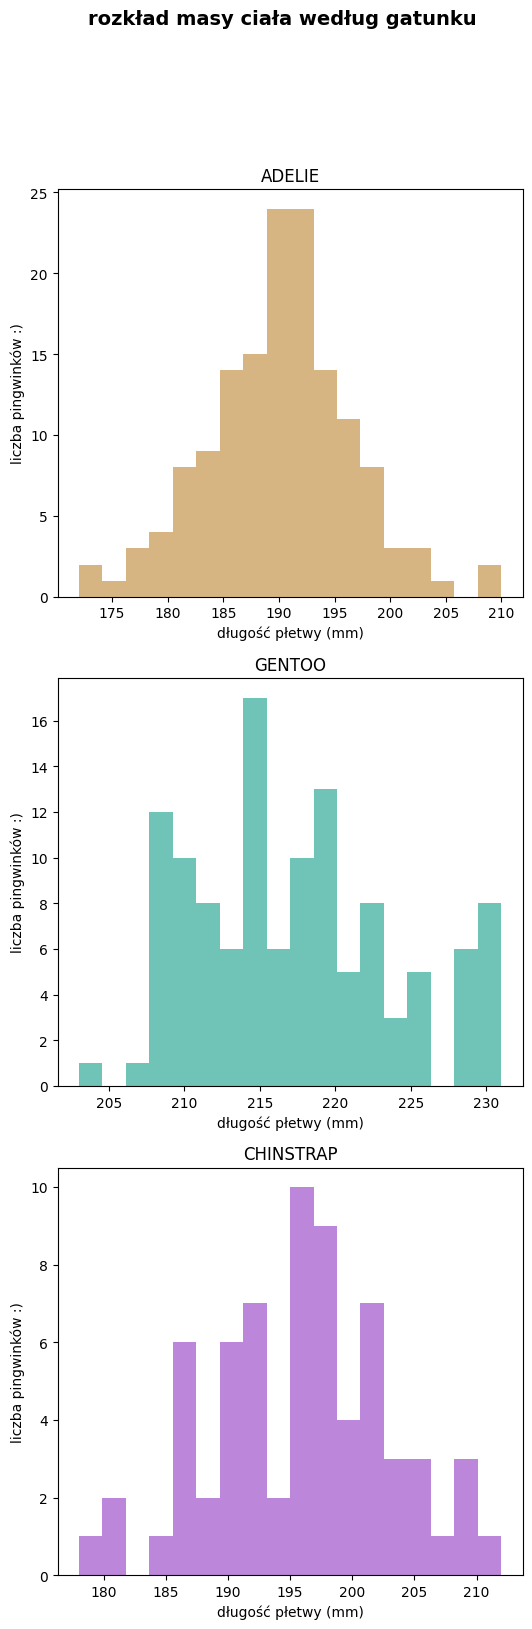

In [36]:
fig, axes = plt.subplots(3, 1, figsize=(6,18))

axes[0].hist(ping[ping["species"]=="Adelie"]["flipper_length_mm"], color=KOLORY["Adelie"], bins=18)
axes[0].set_xlabel("długość płetwy (mm)")
axes[0].set_ylabel("liczba pingwinków :)")
axes[0].set_title("ADELIE")

axes[1].hist(ping[ping["species"]=="Gentoo"]["flipper_length_mm"], color=KOLORY["Gentoo"], bins=18)
axes[1].set_xlabel("długość płetwy (mm)")
axes[1].set_ylabel("liczba pingwinków :)")
axes[1].set_title("GENTOO")

axes[2].hist(ping[ping["species"]=="Chinstrap"]["flipper_length_mm"], color=KOLORY["Chinstrap"], bins=18)
axes[2].set_xlabel("długość płetwy (mm)")
axes[2].set_ylabel("liczba pingwinków :)")
axes[2].set_title("CHINSTRAP")

fig.suptitle("rozkład masy ciała według gatunku", fontsize=14, fontweight="bold")
plt.show()

#albo pojedynczy albo takie laczne wykresy, nie mozna tutaj dołożyć jakiegos wczesniejszego wykresu
#jesli wiemy ze bedziemy czesto uzywac danego wykresu to napisac sobie funkcje po prostu z tego (albo pobrac obrazy)

### 8.3 Mieszany układ — wykres słupkowy obok scatter plot

Siatka 1×2 z dwoma różnymi typami wykresów.

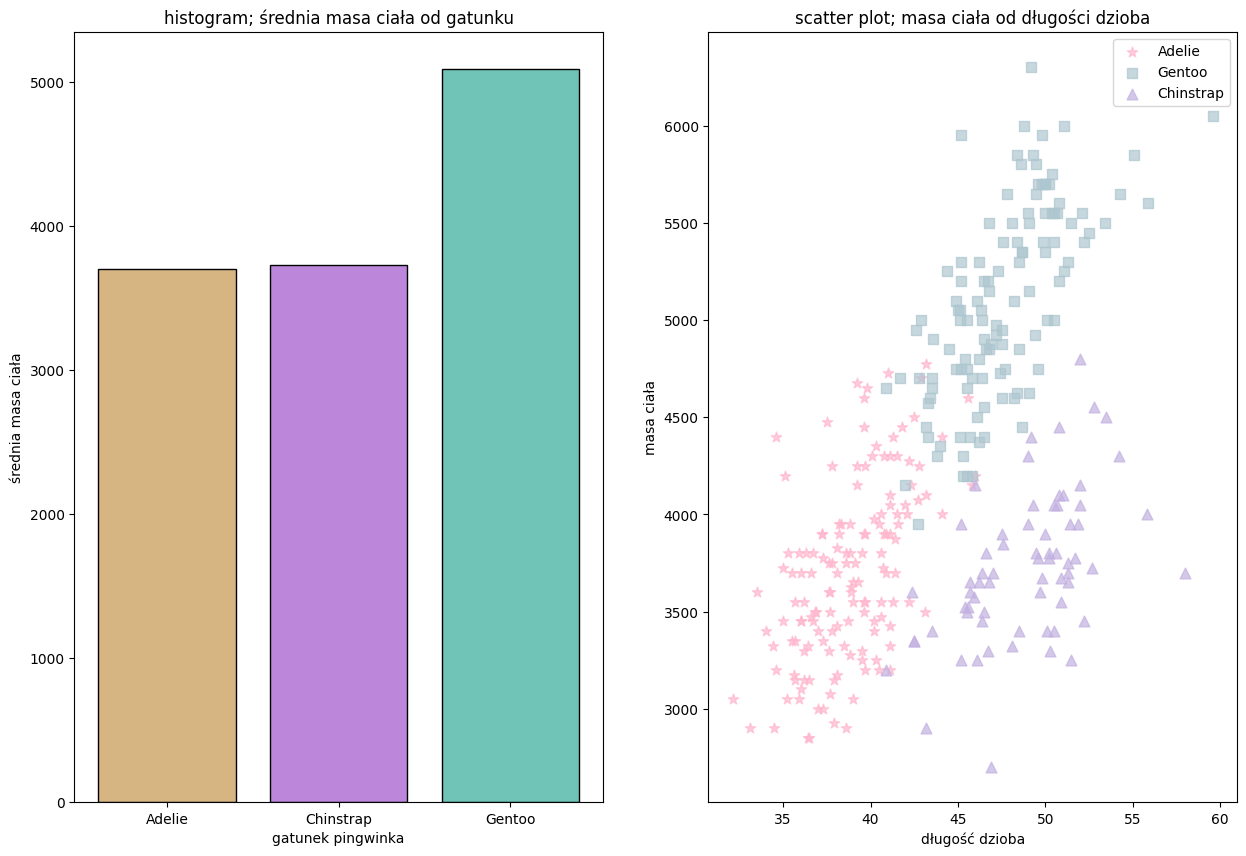

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15,10))

mass = ping.groupby("species")["body_mass_g"].mean()

axes[0].bar(mass.index, #indexy to nazwy gatunkow
            mass.values, #values to srednie
            color=[KOLORY[gatunek] for gatunek in mass.index],
            edgecolor="black"
)
axes[0].set_xlabel("gatunek pingwinka")
axes[0].set_ylabel("średnia masa ciała")
axes[0].set_title("histogram; średnia masa ciała od gatunku")


markery = {'Adelie' : '*', 'Gentoo' : 's', 'Chinstrap' : '^'}
for gatunek, kolor in COLORY.items():
  boom = ping[ping['species']==gatunek]
  axes[1].scatter(boom['bill_length_mm'], boom['body_mass_g'], c=kolor, label=gatunek, s =60, marker =markery[gatunek], alpha = 0.7 )
axes[1].set_xlabel("długość dzioba")
axes[1].set_ylabel("masa ciała")
axes[1].set_title("scatter plot; masa ciała od długości dzioba")
axes[1].legend()

#lista_wyraz=[for element in lista]

###  Zadanie 8

Utwórz siatkę `plt.subplots(2, 2)` z czterema wykresami:
- `axes[0, 0]` — histogram masy ciała (z podziałem na gatunki)
- `axes[0, 1]` — boxplot długości płetwy (wg gatunku, użyj `sns.boxplot(..., ax=axes[0,1])`)
- `axes[1, 0]` — scatter długość dzioba vs głębokość dzioba
- `axes[1, 1]` — heatmapa korelacji (`sns.heatmap(..., ax=axes[1,1])`)

> 💡 Dla siatki 2×2: `axes[wiersz, kolumna]` np. `axes[0, 0]`, `axes[1, 1]`

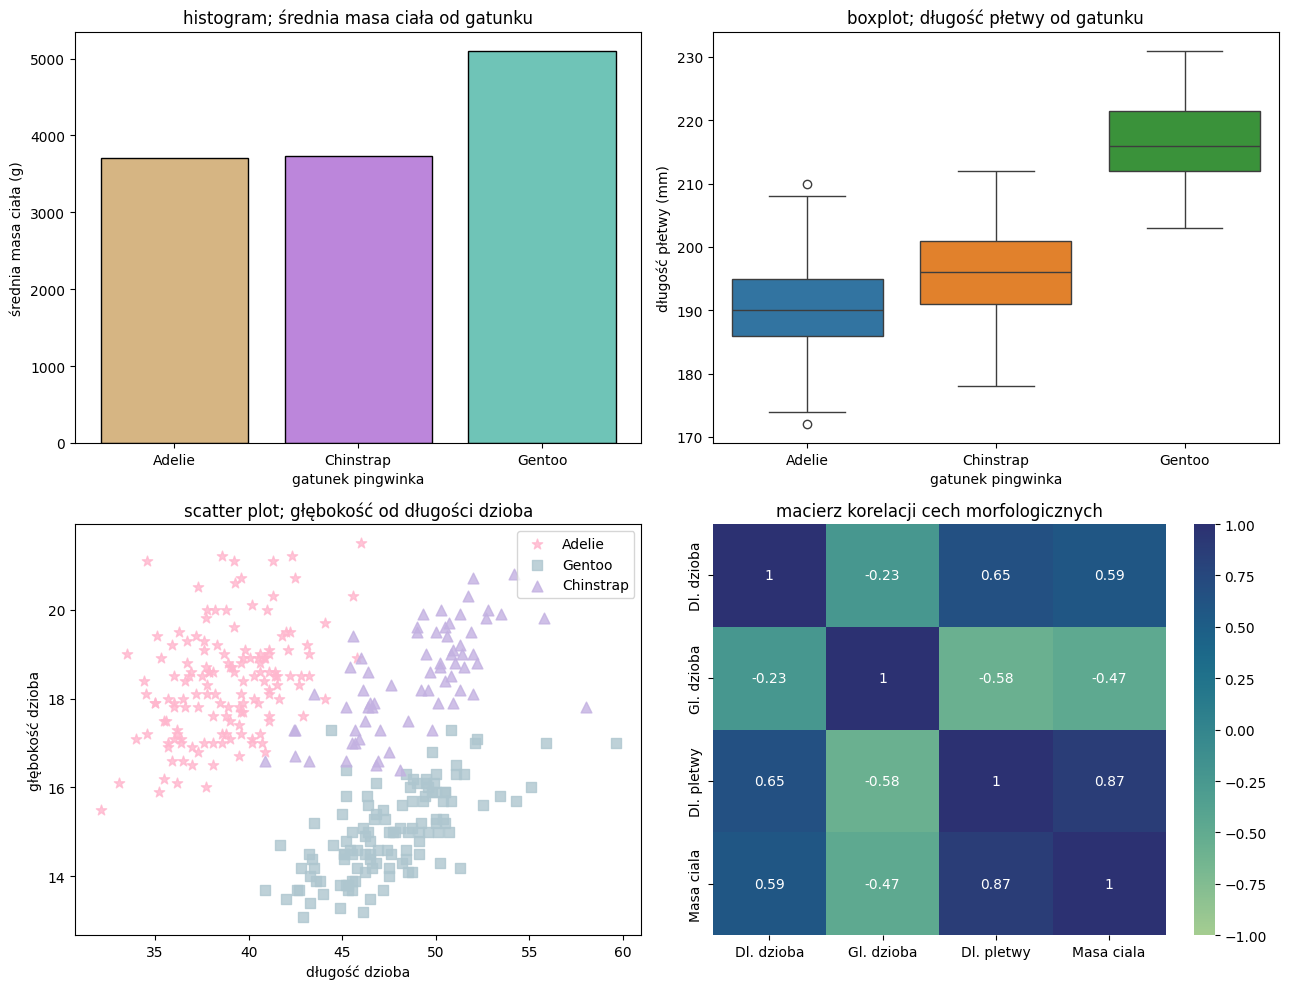

In [38]:
# Twoje rozwiązanie:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# axes[0, 0] — histogram masy ciała
mass = ping.groupby("species")["body_mass_g"].mean()

axes[0, 0].bar(mass.index, #indexy to nazwy gatunkow
            mass.values, #values to srednie
            color=[KOLORY[gatunek] for gatunek in mass.index],
            edgecolor="black"
            )
axes[0, 0].set_xlabel("gatunek pingwinka")
axes[0, 0].set_ylabel("średnia masa ciała (g)")
axes[0, 0].set_title("histogram; średnia masa ciała od gatunku")

# axes[0, 1] — boxplot dlugosci pletwy
# sns.boxplot(data=df, x='species', y='flipper_length_mm', ..., ax=axes[0, 1])
sns.boxplot(data=ping,
            x="species",
            y="flipper_length_mm",
            hue="species",
            ax=axes[0, 1]
            )
axes[0, 1].set_xlabel("gatunek pingwinka")
axes[0, 1].set_ylabel("długość płetwy (mm)")
axes[0, 1].set_title("boxplot; długość płetwy od gatunku")

# axes[1, 0] — scatter ksztaltu dzioba
markery = {'Adelie' : '*', 'Gentoo' : 's', 'Chinstrap' : '^'}
for gatunek, kolor in COLORY.items():
  boom = ping[ping['species']==gatunek]
  axes[1, 0].scatter(boom['bill_length_mm'], boom['bill_depth_mm'], c=kolor, label=gatunek, s =60, marker =markery[gatunek], alpha = 0.8 )
axes[1, 0].set_xlabel("długość dzioba")
axes[1, 0].set_ylabel("głębokość dzioba")
axes[1, 0].set_title("scatter plot; głębokość od długości dzioba")
axes[1, 0].legend()

# axes[1, 1] — heatmapa korelacji
# sns.heatmap(corr, ..., ax=axes[1, 1])
cechy    = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
etykiety = ['Dl. dzioba', 'Gl. dzioba', 'Dl. pletwy', 'Masa ciala']
corr = ping[cechy].corr()

sns.heatmap(corr,
            annot=True, #pokazuje wartosc na kazdym kafelku macierzy
            cmap="crest", #zmiana map kolorów
            vmin= -1, vmax= 1, #ustawia skale (z boku)
            xticklabels=etykiety, #dodanie custom etykiet
            yticklabels=etykiety,
            ax=axes[1, 1]
            )

axes[1, 1].set_title("macierz korelacji cech morfologicznych")

plt.tight_layout()
plt.show()

---
## 9. Seaborn — te same wykresy, mniej kodu


Seaborn to nakładka na Matplotlib. Rozumie ramki danych pandas bezpośrednio  
i obsługuje grupowanie jednym parametrem `hue=`.

**Kluczowa różnica:**
```python
# Matplotlib — pętla, ręczne filtrowanie
for gatunek, kolor in KOLORY.items():
    dane = df[df['species'] == gatunek]['body_mass_g']
    plt.hist(dane, alpha=0.6, color=kolor, label=gatunek)
plt.legend()

# Seaborn — jedna linia robi to samo
sns.histplot(data=df, x='body_mass_g', hue='species')
```

Matplotlib zostaje "pod spodem" — `plt.title()`, `plt.xlabel()`, `plt.savefig()` działają tak samo.

In [39]:
sns.set_theme(style='whitegrid')   # globalny styl — działa na wszystkie kolejne wykresy
print('Seaborn gotowy!')

Seaborn gotowy!


### 9.1 sns.histplot z KDE

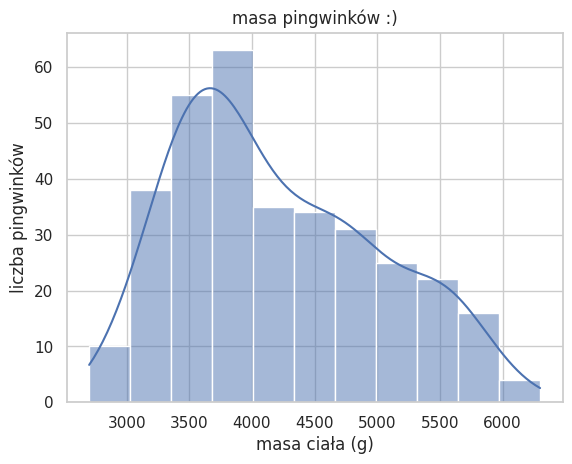

In [40]:
sns.histplot(data=ping, x='body_mass_g', kde=True) #kde to kernel density estimation curve
plt.xlabel("masa ciała (g)")
plt.ylabel("liczba pingwinków")
plt.title("masa pingwinków :)")
plt.show()

### 9.2 sns.boxplot z hue — podział na płeć jednym parametrem

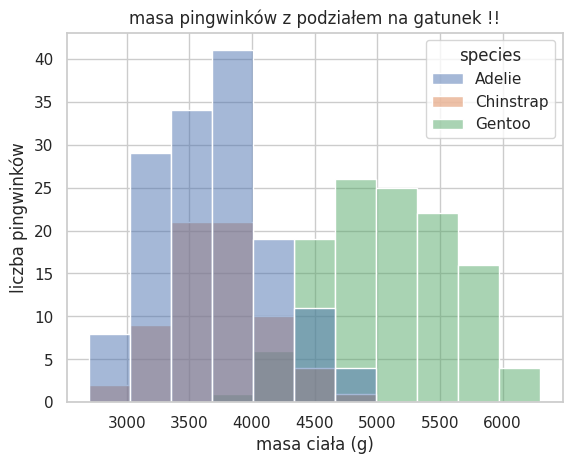

In [44]:
sns.histplot(data=ping, x='body_mass_g', hue='species')
plt.xlabel("masa ciała (g)")
plt.ylabel("liczba pingwinków")
plt.title("masa pingwinków z podziałem na gatunek !!")
plt.show()

### 9.3 sns.scatterplot i sns.heatmap

Text(0.5, 1.0, 'macierz korelacji masy ciała i długości dzioba')

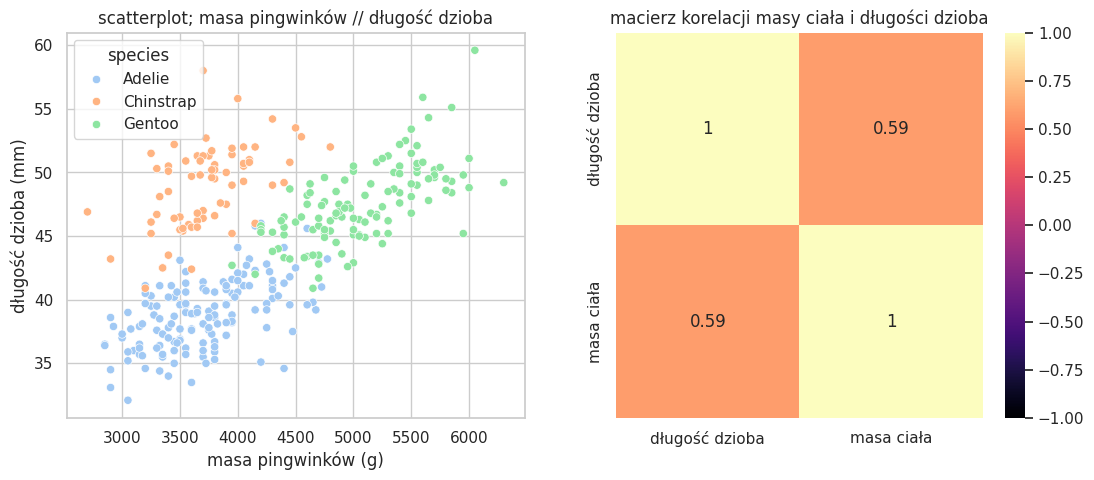

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=ping, x="body_mass_g", y="bill_length_mm", hue="species", palette="pastel", markers=True, ax=axes[0])
axes[0].set_title("scatterplot; masa pingwinków // długość dzioba")
axes[0].set_ylabel("długość dzioba (mm)")
axes[0].set_xlabel("masa pingwinków (g)")


cechy    = ['bill_length_mm', 'body_mass_g']
etykiety = ["długość dzioba", "masa ciała"]
corr2 = ping[cechy].corr()
sns.heatmap(corr2,
            annot=True, #pokazuje wartosc na kazdym kafelku macierzy
            cmap="magma", #zmiana map kolorów
            vmin= -1, vmax= 1, #ustawia skale (z boku)
            xticklabels=etykiety, #dodanie custom etykiet
            yticklabels=etykiety,
            ax=axes[1]
            )

axes[1].set_title("macierz korelacji masy ciała i długości dzioba")


### 9.4 sns.pairplot — wszystkie pary naraz

`sns.pairplot` rysuje macierz wykresów: każda cecha vs każda inna cecha.  
Na przekątnej — rozkłady (histogram lub KDE). Poza przekątną — scatter plot.

<Figure size 1300x1300 with 0 Axes>

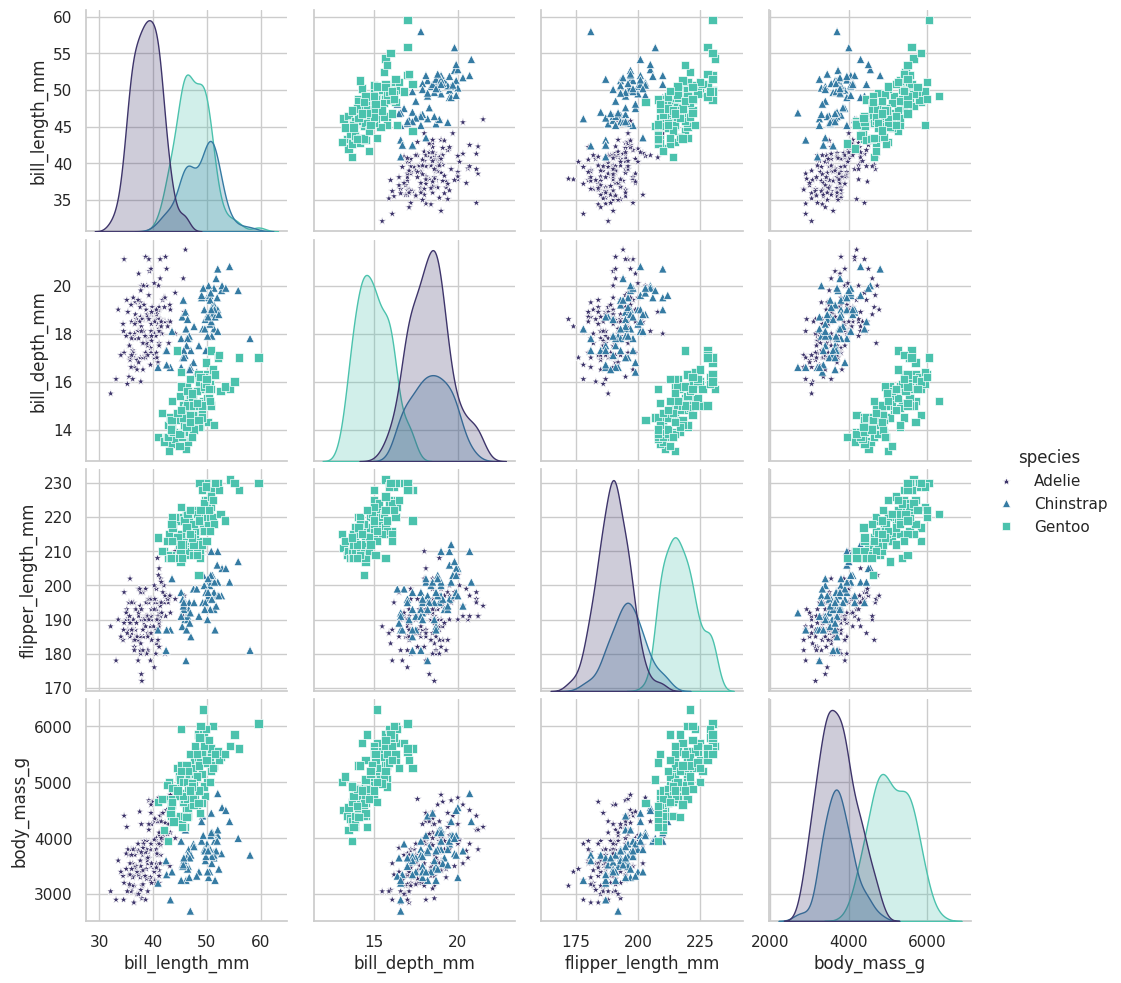

In [75]:
plt.figure(figsize=(13, 13))
marks = {'Adelie' : '*', 'Gentoo' : 's', 'Chinstrap' : '^'}
sns.pairplot(data=ping, 
             hue="species", 
             palette="mako",
             #vars - jakie zmienne uzyć, dla none zrobi dla każdej numerycznej
             kind="scatter", 
             diag_kind="kde",
             markers=marks
            )

###  Zadanie 9

1. Narysuj `sns.violinplot` dla `body_mass_g` z podziałem na gatunki i płeć (`hue='sex'`).  
   Porównaj z boxplotem z Zadania 5 — co violinplot mówi więcej?

2. Użyj `sns.pairplot` ale z `diag_kind='hist'` zamiast `'kde'`. Czy coś się zmieniło?

3. Utwórz subplots `1×3` z trzema wykresami Seaborn obok siebie:
   - violinplot długości dzioba
   - boxplot masy ciała
   - scatterplot długość vs głębokość dzioba

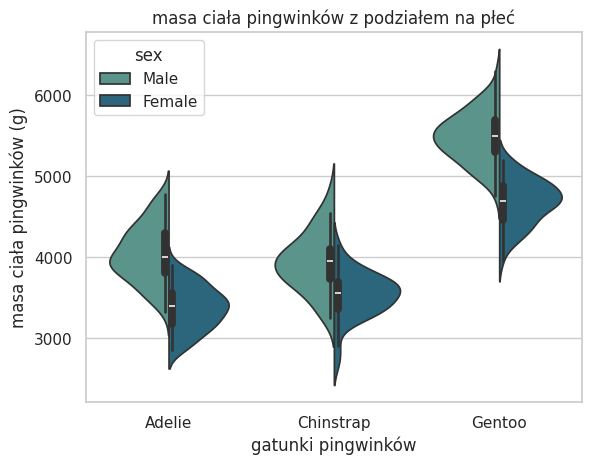

In [81]:
# Twoje rozwiązanie — zadanie 1:

sns.violinplot(data=ping, x="species", y="body_mass_g", hue="sex", palette="crest", split=True)
#split pozwala na połączenie (połówki) dla wykresów male/female dla łatwiejszego porównania
plt.title("masa ciała pingwinków z podziałem na płeć")
plt.xlabel("gatunki pingwinków")
plt.ylabel("masa ciała pingwinków (g)")
plt.show()


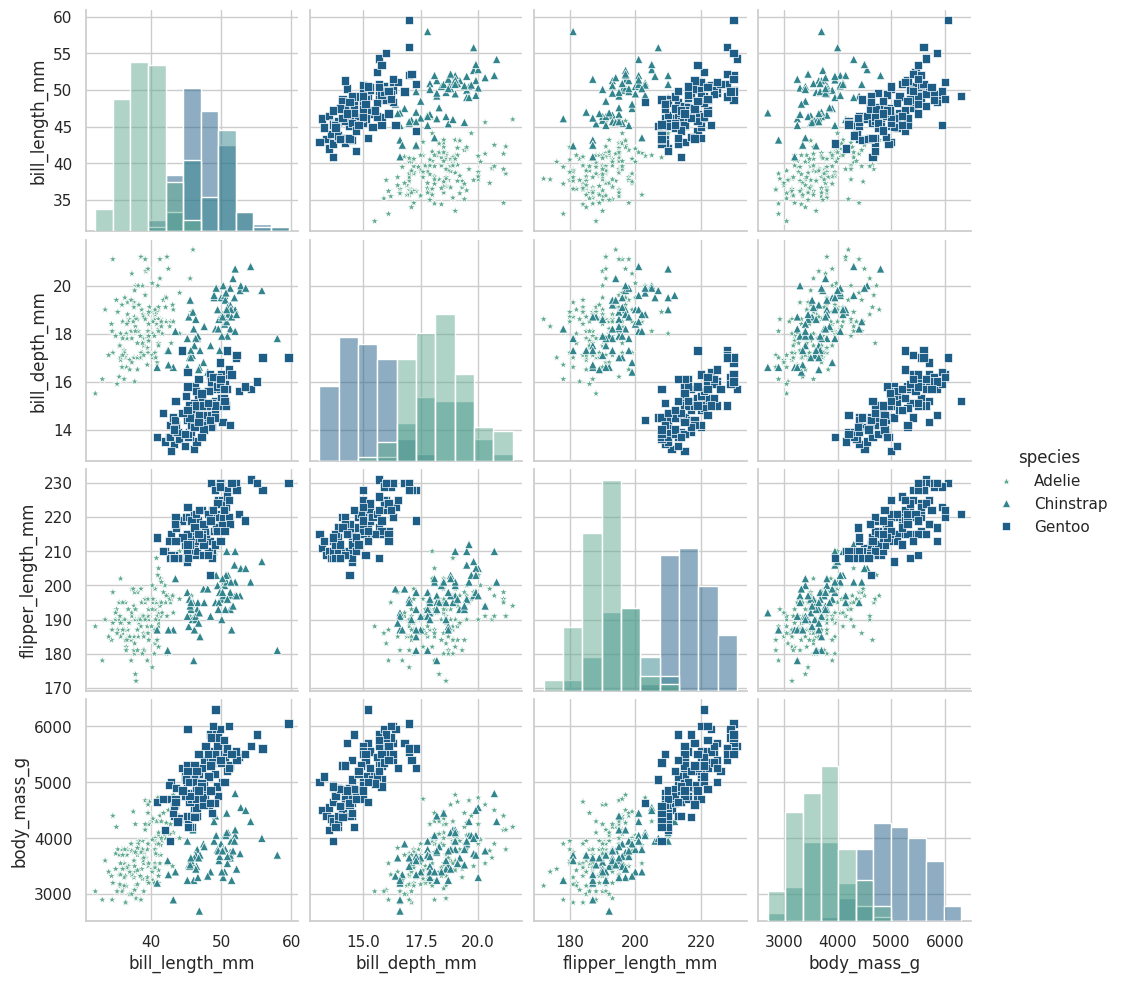

In [83]:
# Twoje rozwiązanie — zadanie 2:
sns.pairplot(data=ping, 
             hue="species", 
             palette="crest", 
             kind="scatter", 
             diag_kind="hist",
             markers=marks)

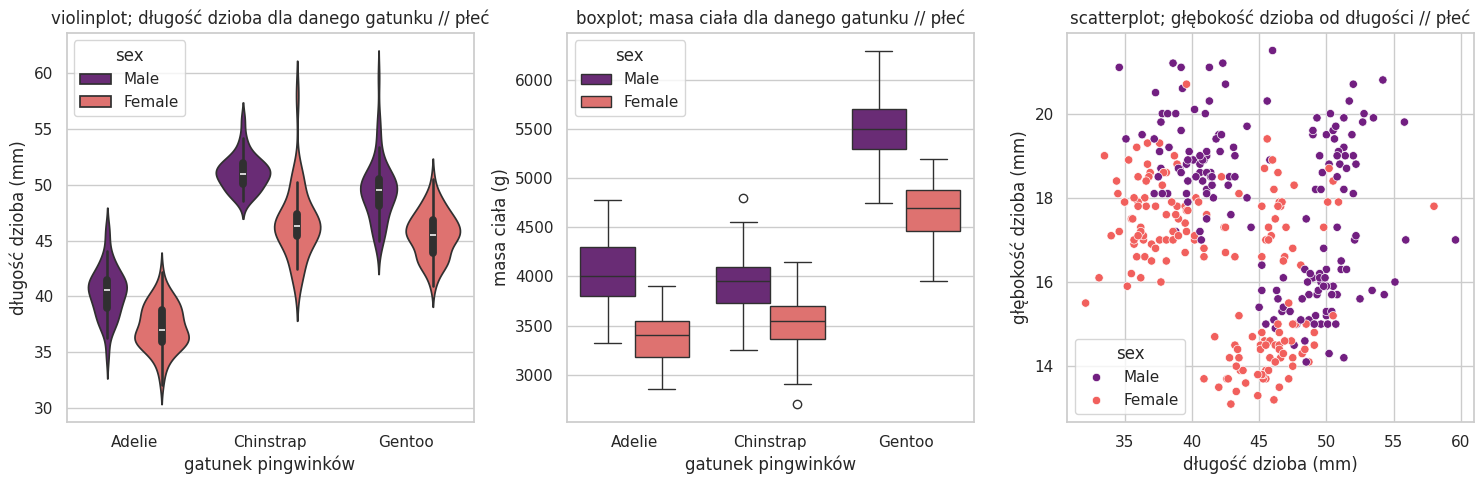

In [86]:
# Twoje rozwiązanie — zadanie 3:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# axes[0] — violinplot
sns.violinplot(data=ping, x="species", y="bill_length_mm", hue="sex", palette="magma", ax=axes[0])
axes[0].set_title("violinplot; długość dzioba dla danego gatunku // płeć")
axes[0].set_xlabel("gatunek pingwinków")
axes[0].set_ylabel("długość dzioba (mm)")
# axes[1] — boxplot
sns.boxplot(data=ping, x="species", y="body_mass_g", hue="sex", palette="magma", ax=axes[1])
axes[1].set_title("boxplot; masa ciała dla danego gatunku // płeć")
axes[1].set_xlabel("gatunek pingwinków")
axes[1].set_ylabel("masa ciała (g)")
# axes[2] — scatterplot
sns.scatterplot(data=ping, x="bill_length_mm", y="bill_depth_mm", hue="sex", palette="magma", markers=marks, ax=axes[2])
axes[2].set_title("scatterplot; głębokość dzioba od długości // płeć")
axes[2].set_xlabel("długość dzioba (mm)")
axes[2].set_ylabel("głębokość dzioba (mm)")

plt.tight_layout()
plt.show()

---
## Podsumowanie

### Matplotlib — kiedy używać?
- Pełna kontrola nad każdym elementem wykresu
- Własne pętle, niestandardowe układy
- `plt.annotate` — wskazywanie konkretnych punktów

### Seaborn — kiedy używać?
- Szybka eksploracja danych z grupowaniem (`hue=`)
- `pairplot` — bez odpowiednika w Matplotlib

### Mapa funkcji

| Zadanie | Matplotlib | Seaborn |
|---------|------------|---------|
| Linia | `plt.plot()` | — |
| Punkty | `plt.scatter()` | `sns.scatterplot()` |
| Histogram | `plt.hist()` | `sns.histplot()` |
| Boxplot | `plt.boxplot()` | `sns.boxplot()` |
| Violinplot | — | `sns.violinplot()` |
| Heatmapa | `plt.imshow()` | `sns.heatmap()` |
| Linia pionowa | `plt.axvline()` | — |
| Wiele wykresów | `plt.subplots()` | `ax=` w sns |
| Wszystkie pary | — | `sns.pairplot()` |
| Grupowanie danych | ręczna pętla | `hue='kolumna'` |

### Cechy dobrego wykresu
- Tytuł, etykiety obu osi **z jednostkami**, legenda
- `alpha` gdy dane się nakładają
- `plt.tight_layout()` zapobiega nakładaniu etykiet
- Spójna paleta kolorów przez cały projekt